6e10: Train on MTG, test on A9

In [1]:
%reset -f

import pickle # loading pair features
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedGroupKFold, GroupKFold
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)

from sklearn.base import clone

from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor
)


import matplotlib.pyplot as plt




from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor
    )


np.random.seed(42)
rseed = 42

print("Starting SEA-AD regression analysis...")


# ============================================================
# Helper functions
# ============================================================

def concordance_correlation_coefficient(y_true, y_pred):
    """
    Calculate Concordance Correlation Coefficient (CCC)
    CCC = 2 * pearson_corr * std_true * std_pred / (var_true + var_pred + (mean_true - mean_pred)^2)
    # LC followed the formula from Dream SEAAD 17'59'' video
    """
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    
    # Calculate Pearson correlation coefficient
    numerator = np.sum((y_true - mean_true) * (y_pred - mean_pred))
    denominator = np.sqrt(np.sum((y_true - mean_true)**2) * np.sum((y_pred - mean_pred)**2))
    
    if denominator == 0:
        pearson_corr = 0
    else:
        pearson_corr = numerator / denominator
    
    # Calculate CCC
    ccc = (2 * pearson_corr * np.std(y_true) * np.std(y_pred)) / (var_true + var_pred + (mean_true - mean_pred)**2)
    
    return ccc

def create_stratification_bins(y, n_bins=5, min_samples_per_bin=3):
    """
    Create better stratification bins for skewed regression targets
    Uses quantile-based binning with minimum sample size per bin
    """
    # Start with quantile-based bins
    bins = pd.qcut(y, q=n_bins, labels=False, duplicates='drop')
    return bins

# ============================================================
# Models
# ============================================================
models = {
    'GradientBoosting_huber': GradientBoostingRegressor(
        n_estimators=600, learning_rate=0.03, max_depth=3,
        subsample=0.8, loss='huber', random_state=rseed
    ),
    'ExtraTreesEnhanced': ExtraTreesRegressor(
        n_estimators=500, max_depth=None, min_samples_split=2,
        min_samples_leaf=1, n_jobs=-1, random_state=rseed
    ),
    'RandomForestRegressor': RandomForestRegressor(
        n_estimators=500, max_depth=None, min_samples_split=2,
        min_samples_leaf=1, n_jobs=-1, random_state=rseed
    )  
}

print(f"Train {len(models)}  models in total.")

# ============================================================
# Add the entire augmentation and  minority augmentation 
# ============================================================
def noise_augmentation(X_train, y_train, n_samples=50, noise_level=0.05, clinical_cols=8):
    """
    Add Gaussian noise to omics features only.
    Clinical features (first N columns) remain unchanged.

    LC: This function should be called INSIDE each CV fold using only
    the training split to avoid data leakage.
    """
    np.random.seed(42)
    indices = np.random.choice(len(X_train), size=n_samples, replace=True)

    X_augmented = []
    y_augmented = []

    for idx in indices:
        x_sample = X_train.iloc[idx].values.copy()
        y_sample = y_train.iloc[idx]

        # Split clinical vs omics
        clinical_part = x_sample[:clinical_cols]
        omics_part = x_sample[clinical_cols:]

        # Apply noise ONLY to omics
        noise = np.random.normal(0, noise_level, size=omics_part.shape)
        omics_noisy = omics_part * (1 + noise)

        # Recombine
        x_noisy = np.concatenate([clinical_part, omics_noisy])

        X_augmented.append(x_noisy)

        # We can still allow slight noise for y as well 
        # + np.random.normal(0, y_train.std() * noise_level)
        y_noisy = y_sample 
        y_augmented.append(y_noisy)


    X_aug_df = pd.DataFrame(X_augmented, columns=X_train.columns)
    y_aug_series = pd.Series(y_augmented)

    return X_aug_df, y_aug_series

def targeted_minority_augmentation(X_train, y_train, threshold=6.0, augment_factor=2.0, 
                                   noise_level=0.1, clinical_cols=3):
    """
    Targeted augmentation for minority class (high target values).
    Only augments samples with y > threshold to balance the dataset.
    
    X_train: Training features
    y_train: Training targets
    threshold: Samples with y > threshold are considered minority
    augment_factor: How many times to augment minority samples (e.g., 2.0 = double them)
    noise_level: Amount of Gaussian noise to add
    clinical_cols: Number of clinical columns to preserve without noise

    """
    # Identify minority samples
    minority_mask = y_train > threshold
    n_minority = minority_mask.sum()
    
    if n_minority == 0:
        print("  No minority samples found, skipping augmentation")
        return X_train, y_train
    
    # Synthetic samples to create
    n_synthetic = int(n_minority * (augment_factor - 1))
    
    if n_synthetic == 0:
        return X_train, y_train
    
    # Get minority samples
    X_minority = X_train[minority_mask]
    y_minority = y_train[minority_mask]
    
    X_augmented = []
    y_augmented = []
    
    # Create synthetic samples by adding noise to minority samples
    for _ in range(n_synthetic):
        # Randomly select a minority sample
        idx = np.random.randint(0, len(X_minority))
        x_sample = X_minority.iloc[idx].values.copy()
        y_sample = y_minority.iloc[idx]
        
        # Split clinical vs omics
        clinical_part = x_sample[:clinical_cols]
        omics_part = x_sample[clinical_cols:]
        
        # Apply noise ONLY to omics features/fraction? 
        noise = np.random.normal(0, noise_level, size=omics_part.shape)
        omics_noisy = omics_part * (1 + noise)
        
        # Combine 
        x_noisy = np.concatenate([clinical_part, omics_noisy])
        
        X_augmented.append(x_noisy)
        # Keep y value close to original with small perturbation
        y_noisy = y_sample + np.random.normal(0, y_train.std() * 0.05)
        y_augmented.append(y_noisy)
    
    # Combine original and augmented data
    X_aug_df = pd.DataFrame(X_augmented, columns=X_train.columns)
    y_aug_series = pd.Series(y_augmented)
    
    X_combined = pd.concat([X_train, X_aug_df], axis=0, ignore_index=True)
    y_combined = pd.concat([y_train, y_aug_series], axis=0, ignore_index=True)
    
    return X_combined, y_combined


def targeted_minority_duplication(X_train, y_train, threshold=6.0, augment_factor=2.0):
    """
    Duplicate minority samples (y > threshold) without adding any noise.
    
    X_train: Training features (DataFrame)
    y_train: Training targets (Series)
    threshold: Samples with y > threshold are considered minority
    augment_factor: How many times to augment minority samples (e.g., 2.0 = duplicate set entirely once)
    """

    # Identify minority samples
    minority_mask = y_train > threshold
    n_minority = minority_mask.sum()

    if n_minority == 0:
        print("  No minority samples found, skipping duplication")
        return X_train, y_train
    
    # Number of duplicates to create
    n_duplicates = int(n_minority * (augment_factor - 1))

    if n_duplicates == 0:
        return X_train, y_train

    # Extract minority samples
    X_minority = X_train[minority_mask]
    y_minority = y_train[minority_mask]

    # Randomly sample *with replacement* to create duplicates
    X_dup = X_minority.sample(n=n_duplicates, replace=True, random_state=None)
    y_dup = y_minority.sample(n=n_duplicates, replace=True, random_state=None)

    # Combine original and duplicated data
    X_combined = pd.concat([X_train, X_dup], axis=0, ignore_index=True)
    y_combined = pd.concat([y_train, y_dup], axis=0, ignore_index=True)

    return X_combined, y_combined



def evaluate_models(X_mtg, y_mtg, X_a9, y_a9, groups_mtg, models = models, verbose = False, CV_num = 5,
                    use_minority_augmentation=False, minority_threshold=6.0, noise_level=0.2, augment_factor=2.0,
                    use_augmentation=False, aug_samples=200, clinical_cols=3):
   
    # ============================================================
    # Improved Cross-Validation with OOF predictions
    # ============================================================

    print("\n" + "="*60)
    print("IMPROVED CROSS-VALIDATION ON MTG DATA")
    print("="*60)

    # Better stratification for skewed target
    # groups_mtg = mtg_df['Donor ID']
    # groups_mtg = mtg_df.index
    y_mtg_bins = create_stratification_bins(y_mtg, n_bins=4, min_samples_per_bin=5) # LC: tested n_bins 3, 4, 5. 4 is the best  

    # Use 5-fold CV for better stability
    # Improvement: using the bin -- LC: this improves the CV stability a lot!
    try:
        cv_splitter = StratifiedGroupKFold(n_splits=CV_num, shuffle=True, random_state=rseed)
        cv_splits = list(cv_splitter.split(X_mtg, y_mtg_bins, groups_mtg)) # Each fold has similar bin distribution
        print(f"Using StratifiedGroupKFold with {CV_num} folds")
    except ValueError as e:
        print(f"StratifiedGroupKFold failed: {e}")
        print("Falling back to GroupKFold")
        cv_splitter = GroupKFold(n_splits=5)
        cv_splits = list(cv_splitter.split(X_mtg, y_mtg, groups_mtg))

    print(f"Created {len(cv_splits)} CV folds")

    # Check fold sizes
    if verbose:
        for i, (train_idx, val_idx) in enumerate(cv_splits):
            print(f"Fold {i+1}: Train={len(train_idx)}, Val={len(val_idx)}")

    # OOF predictions; metrics storage: ccc, r2, mse according to challenge "We will also show the performance in mean squared errors (MSE) and in R2, though these metrics will not be used for ranking."
    oof_predictions = {}
    cv_results = {}
    for name, base_model in models.items():
        if verbose:
            print(f"\n--- Evaluating {name} ---")
        
        fold_cccs, fold_r2s, fold_mses = [], [], []
        oof_preds = np.full(len(y_mtg), np.nan)
        
        for fold, (train_idx, val_idx) in enumerate(cv_splits):
            X_train_fold = X_mtg.iloc[train_idx]
            X_val_fold = X_mtg.iloc[val_idx]
            y_train_fold = y_mtg.iloc[train_idx]
            y_val_fold = y_mtg.iloc[val_idx]

            # -------------------------------------------------------------------
            # Apply targeted minority augmentation and augmentation inside CV fold
            if use_minority_augmentation:
                n_before = len(X_train_fold)
                minority_count_before = (y_train_fold > minority_threshold).sum()
                majority_count_before = (y_train_fold <= minority_threshold).sum()
                
                if verbose and fold == 0:
                    print(f"  Before augmentation: {n_before} samples")
                    print(f"    Minority (>{minority_threshold}): {minority_count_before} samples")
                    print(f"    Majority (≤{minority_threshold}): {majority_count_before} samples")
                
                X_train_fold, y_train_fold = targeted_minority_augmentation(
                    X_train_fold, y_train_fold, 
                    threshold=minority_threshold,
                    augment_factor=augment_factor,
                    noise_level=noise_level,
                    clinical_cols=clinical_cols
                )
                
                # X_train_fold, y_train_fold = targeted_minority_duplication(
                #     X_train_fold, y_train_fold, 
                #     threshold=minority_threshold,
                #     augment_factor=augment_factor
                # )                
                n_after = len(X_train_fold)
                minority_count_after = (y_train_fold > minority_threshold).sum()
                
                if verbose and fold == 0:
                    print(f"  After augmentation: {n_after} samples (+{n_after - n_before})")
                    print(f"    Minority (>{minority_threshold}): {minority_count_after} samples")

            if use_augmentation:
                X_synth, y_synth = noise_augmentation(
                    X_train_fold, y_train_fold, n_samples=aug_samples,
                    noise_level=noise_level, clinical_cols=clinical_cols
                )
                X_train_fold = pd.concat([X_train_fold, X_synth], axis=0, ignore_index=True)
                y_train_fold = pd.concat([y_train_fold, y_synth], axis=0, ignore_index=True)
                if verbose and fold == 0:
                    print(f"  Augmented training: {len(X_train_fold)} samples (original + synthetic)")
            # -------------------------------------------------------------------

            model = clone(base_model)
            try:
                model.fit(X_train_fold, y_train_fold)
                y_pred_fold = model.predict(X_val_fold)
                oof_preds[val_idx] = y_pred_fold

                ccc = concordance_correlation_coefficient(y_val_fold, y_pred_fold)
                r2 = r2_score(y_val_fold, y_pred_fold)
                mse = mean_squared_error(y_val_fold, y_pred_fold)

            except Exception as e:
                print(f"  Fold {fold+1} FAILED: {e}")
                ccc = np.nan
                r2 = np.nan
                mse = np.nan

            fold_cccs.append(ccc)
            fold_r2s.append(r2)
            fold_mses.append(mse)
            if verbose:
                print(f"  Fold {fold+1}: CCC={ccc:.4f}, R2={r2:.4f}, MSE={mse:.4f}")

        # OOF metrics, OOF predictions for every sample combined
        valid_oof = ~np.isnan(oof_preds)
        if valid_oof.sum() > 0:
            oof_ccc = concordance_correlation_coefficient(y_mtg[valid_oof], oof_preds[valid_oof])  
            oof_r2 = r2_score(y_mtg[valid_oof], oof_preds[valid_oof])
            oof_mse = mean_squared_error(y_mtg[valid_oof], oof_preds[valid_oof])
        else:
            oof_ccc = oof_r2 = oof_mse = np.nan

        cv_results[name] = {
            'mean_ccc': np.nanmean(fold_cccs), 'std_ccc': np.nanstd(fold_cccs),
            'mean_r2': np.nanmean(fold_r2s), 'std_r2': np.nanstd(fold_r2s),
            'mean_mse': np.nanmean(fold_mses), 'std_mse': np.nanstd(fold_mses),
            'oof_ccc': oof_ccc, 'oof_r2': oof_r2, 'oof_mse': oof_mse,
            'fold_cccs': fold_cccs, 'fold_r2s': fold_r2s, 'fold_mses': fold_mses
        }

        oof_predictions[name] = oof_preds.copy()
        if verbose:
            print(f"  SUMMARY {name}: mean CCC={cv_results[name]['mean_ccc']:.4f} ± {cv_results[name]['std_ccc']:.4f}, "
                  f"OOF CCC={oof_ccc:.4f}, OOF MSE={oof_mse:.4f}")
        
    # ============================================================
    # Model Selection and Summary
    # ============================================================

    print("\n" + "="*60)
    print("CROSS-VALIDATION RESULTS SUMMARY")
    print("="*60)

    # Sort models by OOF CCC (keep selection by oof_ccc)
    sorted_models = sorted(cv_results.items(), key=lambda x: x[1]['oof_ccc'], reverse=True)

    # Header includes CCC, R2 and MSE 
    print(f"{'Model':<25} {'OOF CCC':<9} {'Mean CCC':<11} {'Std CCC':<9} "
        f"{'OOF R2':<9} {'Mean R2':<9} {'Std R2':<9} "
        f"{'OOF MSE':<10} {'Mean MSE':<10} {'Std MSE':<9}")
    print("-" * 110)
    for name, results in sorted_models:
        print(f"{name:<25} "
            f"{results['oof_ccc']:<9.4f} {results['mean_ccc']:<11.4f} {results['std_ccc']:<9.4f} "
            f"{results['oof_r2']:<9.4f} {results['mean_r2']:<9.4f} {results['std_r2']:<9.4f} "
            f"{results['oof_mse']:<10.4f} {results['mean_mse']:<10.4f} {results['std_mse']:<9.4f}")

    # Select best model (by OOF CCC)
    best_model_name = sorted_models[0][0]
    best_results = sorted_models[0][1]

    print(f"\nBest Model: {best_model_name}")
    print(f"OOF CCC: {best_results['oof_ccc']:.4f}")
    print(f"OOF R²: {best_results['oof_r2']:.4f}")
    print(f"OOF MSE: {best_results['oof_mse']:.4f}")
    print(f"Cross-validation CCC: {best_results['mean_ccc']:.4f} ± {best_results['std_ccc']:.4f}")
    print(f"Cross-validation R²:  {best_results['mean_r2']:.4f} ± {best_results['std_r2']:.4f}")
    print(f"Cross-validation MSE:  {best_results['mean_mse']:.4f} ± {best_results['std_mse']:.4f}")

    # ============================================================
    # Train final model on all MTG data
    # ============================================================
    y_mtg_pred = oof_predictions[best_model_name]
    print("\n" + "="*60)
    print("TRAINING FINAL MODEL ON ALL MTG DATA")
    print("="*60)

    final_model = clone(models[best_model_name])
    print(f"Training {best_model_name} on all {len(X_mtg)} MTG samples...")

    final_model.fit(X_mtg, y_mtg)
    print("Training completed.")

    # Get training predictions. we may see some overfitting here
    y_mtg_pred_final = final_model.predict(X_mtg)
    train_ccc = concordance_correlation_coefficient(y_mtg, y_mtg_pred_final)
    train_r2 = r2_score(y_mtg, y_mtg_pred_final)
    train_rmse = np.sqrt(mean_squared_error(y_mtg, y_mtg_pred_final))

    print(f"\nTraining performance (for reference only - not for evaluation):")
    print(f"  CCC: {train_ccc:.4f}")
    print(f"  R²: {train_r2:.4f}")
    print(f"  RMSE: {train_rmse:.4f}")

    print(f"\nBest generalization estimate (OOF): CCC = {best_results['oof_ccc']:.4f}")


    # ============================================================
    # Test on held-out A9 data
    # ============================================================

    print("\n" + "="*60)
    print("TESTING ON HELD-OUT A9 DATA")
    print("="*60)

    # Make predictions on A9
    print(f"Making predictions on {len(X_a9)} A9 samples...")
    y_a9_pred = final_model.predict(X_a9)

    # Calculate A9 test metrics
    a9_ccc = concordance_correlation_coefficient(y_a9, y_a9_pred)
    a9_r2 = r2_score(y_a9, y_a9_pred)
    a9_rmse = np.sqrt(mean_squared_error(y_a9, y_a9_pred))
    a9_mae = mean_absolute_error(y_a9, y_a9_pred)

    print(f"\nA9 Test Performance ({best_model_name}):")
    print(f"  CCC: {a9_ccc:.4f}")
    print(f"  R²: {a9_r2:.4f}")
    print(f"  RMSE: {a9_rmse:.4f}")
    print(f"  MAE: {a9_mae:.4f}")

    print(f"\n" + "="*60)
    print("PERFORMANCE COMPARISON")
    print("="*60)
    print(f"MTG CV (OOF):     CCC = {best_results['oof_ccc']:.4f}")
    print(f"A9 Test:          CCC = {a9_ccc:.4f}")
    print(f"Generalization:   {a9_ccc/best_results['oof_ccc']:.2f}x CV performance")



    # Summary plot for all models

    oof_cccs   = []
    train_cccs = []
    test_cccs  = []
    model_names = []

    for name, base_model in models.items():

        # --- OOF CCC (already computed earlier) ---
        oof_cccs.append(cv_results[name]['oof_ccc'])

        # --- Train model on full MTG ---
        model = clone(base_model)
        model.fit(X_mtg, y_mtg)

        # A9 Train-Predict
        y_train_pred = model.predict(X_mtg)
        train_ccc = concordance_correlation_coefficient(y_mtg, y_train_pred)
        train_cccs.append(train_ccc)

        # MTG Test-Predict
        y_test_pred = model.predict(X_a9)
        test_ccc = concordance_correlation_coefficient(y_a9, y_test_pred)
        test_cccs.append(test_ccc)

        model_names.append(name)
        
    plt.figure(figsize=(12, 6))
    x = np.arange(len(model_names))

    plt.bar(x - 0.25, train_cccs, width=0.25, 
            label='MTG Train CCC', color='#a6cee3', alpha=0.8)  
    plt.bar(x, oof_cccs, width=0.25, 
            label='MTG OOF CCC', color='#b2df8a', alpha=0.8)    
    plt.bar(x + 0.25, test_cccs, width=0.25, 
            label='A9 Test CCC', color='#fb9a99', alpha=0.8)  
    plt.xticks(x, model_names, rotation=90)
    plt.ylabel("Concordance Correlation Coefficient (CCC)")
    plt.title("Model Performance Comparison (Train vs OOF vs Test)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return final_model, best_model_name, y_mtg_pred, y_a9_pred


import re


def prepare_features(df, feature_genes, pair_df = None, feature_pairs = None, more_cov = False):
    """
    Prepare features with better handling of categorical variables
    """
    sex_levels = ['Male', 'Female']


    apoe_levels = ['2/2','2/3','2/4','3/3','3/4','4/4']
    all_features =  [f"Sex_{s}" for s in sex_levels] + [f"APOE_{g}" for g in apoe_levels] + feature_genes
    ## Ordinal encoding for APOE
    # apoe_orders = {'2/2': 1, '2/3': 2, '2/4': 3, '3/3': 4, '3/4': 5, '4/4': 6}
    # all_features =  [f"Sex_{s}" for s in sex_levels] + ['APOE_score'] + feature_genes

    
    
    X = pd.DataFrame(0, index=df.index, columns=all_features)

    # Gene features
    for g in feature_genes:
        if g in df.columns:
            X[g] = pd.to_numeric(df[g], errors='coerce')

    # Sex encoding
    if 'Sex' in df.columns:
        for s in sex_levels:
            X.loc[df['Sex'].astype(str) == s, f"Sex_{s}"] = 1

    # # APOE encoding
    if 'APOE Genotype' in df.columns:
        for g in apoe_levels:
            X.loc[df['APOE Genotype'].astype(str) == g, f"APOE_{g}"] = 1
    
    ## Ordinal encoding for APOE
    # if 'APOE Genotype' in df.columns:
    #     X['APOE_score'] = df['APOE Genotype'].map(apoe_orders).fillna(0)
    
    if more_cov:
        X_cov = df[["Age at Death", "Years of education", "PMI"]]
        X = pd.concat([X_cov, X], axis=1)
   
    if pair_df is not None and feature_pairs is not None:

        X_pairs = pair_df.loc[X.index, feature_pairs]

        cell_type = "Microglia-PVM"
        celltype_sanitized = re.sub(r'(\d+)/(\d+)', r'\1-\2', cell_type)
        celltype_sanitized = re.sub(r'\s+', '_', celltype_sanitized)
        X_pairs.columns = celltype_sanitized + '_' + X_pairs.columns

        X = pd.concat([X, X_pairs], axis=1)
    


    # Fill missing values and remove constant columns
    X = X.fillna(0)

    # Remove columns with zero variance
    constant_cols = X.columns[X.var() == 0]
    if len(constant_cols) > 0:
        print(f"Removing {len(constant_cols)} constant columns: {list(constant_cols)}")
        X = X.drop(columns=constant_cols)
    
    return X


Starting SEA-AD regression analysis...
Train 3  models in total.



Feature matrix shapes:
  MTG: (84, 25)
  A9: (80, 25)
  Features: ['Age at Death', 'Years of education', 'PMI', 'Sex_Male', 'Sex_Female', 'APOE_2/2', 'APOE_2/3', 'APOE_2/4', 'APOE_3/3', 'APOE_3/4', 'APOE_4/4', 'AC016590.1', 'MIR3681HG', 'TBC1D3', 'TSPEAR-AS1', 'SHISA6', 'AC009654.1', 'AC026341.2', 'HLA-DRB5', 'LINC02251', 'SLC35D3', 'Microglia-PVM_GRID2_LINC01684', 'Microglia-PVM_OXR1_RGL1', 'Microglia-PVM_IPCEF1_CPM', 'Microglia-PVM_PTPRG_MSR1']

IMPROVED CROSS-VALIDATION ON MTG DATA
Using StratifiedGroupKFold with 5 folds
Created 5 CV folds
Fold 1: Train=67, Val=17
Fold 2: Train=67, Val=17
Fold 3: Train=67, Val=17
Fold 4: Train=67, Val=17
Fold 5: Train=68, Val=16

--- Evaluating GradientBoosting_huber ---
  Fold 1: CCC=0.4479, R2=0.2738, MSE=11.5116
  Fold 2: CCC=0.7747, R2=0.6736, MSE=2.3047
  Fold 3: CCC=0.5684, R2=0.4177, MSE=1.9305
  Fold 4: CCC=0.7374, R2=0.6143, MSE=3.3933
  Fold 5: CCC=0.7625, R2=0.5185, MSE=1.8488
  SUMMARY GradientBoosting_huber: mean CCC=0.6582 ± 0.1288, O

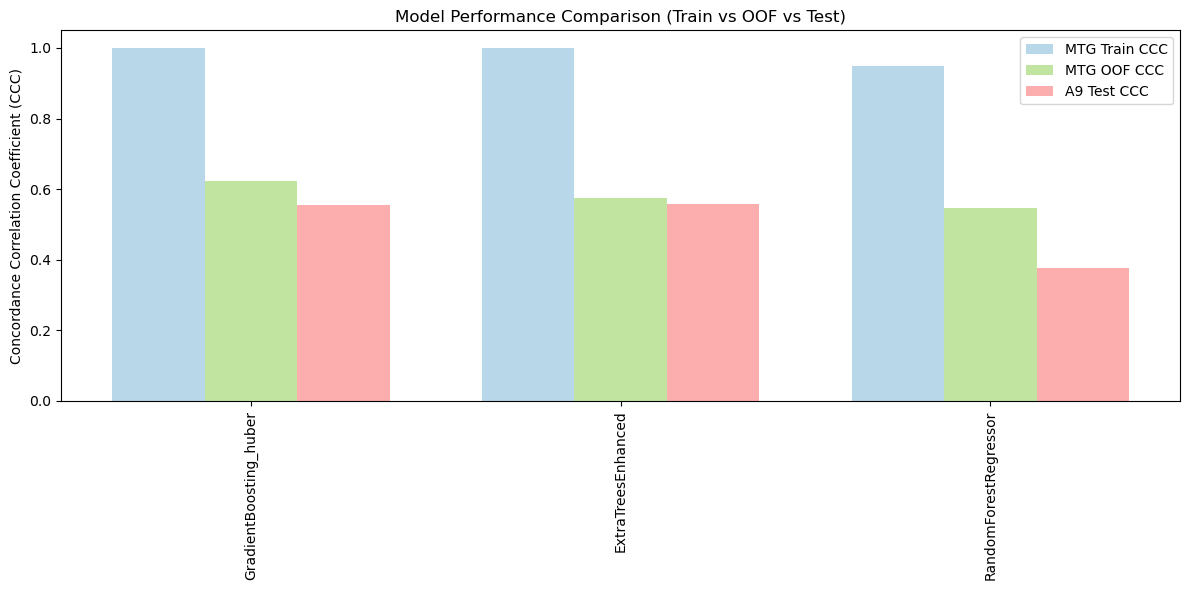

In [2]:
# ============================================================
# Load data
# ============================================================

mtg_file = "/Users/lingyi/Documents/sea-ad/data/csv_fraction_all/SEAAD_MTG_RNAseq_DREAM.2025-07-15_fractions.csv"
a9_file  = "/Users/lingyi/Documents/sea-ad/data/csv_fraction_all/SEAAD_A9_RNAseq_DREAM.2025-07-15_fractions.csv"



mtg_df = pd.read_csv(mtg_file, index_col=0) #index as Donor ID
a9_df  = pd.read_csv(a9_file, index_col=0)



DATA_DIR = "/Users/lingyi/Documents/sea-ad/models/XL_pairs/1028/"
with open(os.path.join(DATA_DIR, "MTG_pair_features_LW_all.pkl"), "rb") as f:   
     pairs_mtg_df = pickle.load(f)

with open(os.path.join(DATA_DIR, "A9_pair_features_LW_all.pkl"), "rb") as f:
     pairs_a9_df = pickle.load(f)


# ============================================================
# Selected gene features and pair features for 6e10; 
# ============================================================

# lingyi = ["CFI", "AC009654.1", "AL031056.1", "TBC1D3", "AC097658.2", "AC016590.1", "LINC02251", "MIR3681HG", "SHISA6", "AC026341.2", 
#           "HLA-DRB5" ,  "AC091435.2","AC005832.1", "AC022517.1" ,"PRORY",
#           "AC104232.2" ,"TTC16"    ,  "LLGL2"  ,    "SLC35D3"  ,  "TSPEAR-AS1"]  # this feature + fraction can reach 0.6 

# MTG sorted training , select the top 10 features
lingyi = ["AC016590.1", "MIR3681HG", "TBC1D3", "TSPEAR-AS1", "SHISA6", "AC009654.1", "AC026341.2", "HLA-DRB5", "LINC02251", "SLC35D3"]


pairs = ['GRID2_LINC01684', 'OXR1_RGL1', 'IPCEF1_CPM'  , 'PTPRG_MSR1']

# ============================================================
# MI genes + pairs + clinical covariates
# ============================================================
# select target
target_col = 'percent 6e10 positive area' 
y_mtg = mtg_df[target_col]
y_a9 = a9_df[target_col]

# select features
X_mtg = prepare_features(mtg_df, lingyi, pairs_mtg_df, pairs, more_cov = True) 
X_a9 = prepare_features(a9_df, lingyi, pairs_a9_df, pairs, more_cov = True)

print(f"\nFeature matrix shapes:")
print(f"  MTG: {X_mtg.shape}")
print(f"  A9: {X_a9.shape}")
print(f"  Features: {list(X_mtg.columns)}")

# ============================================================
# Train and evaluate models, should have the following results:
# MTG CV (OOF):     CCC = 0.6233
# A9 Test:          CCC = 0.5553
# ============================================================
final_model, best_model_name, y_mtg_pred, y_a9_pred= evaluate_models(X_mtg, y_mtg, X_a9, y_a9, groups_mtg = mtg_df.index, models = models, verbose = True, CV_num = 5, clinical_cols=3,
                                                                     noise_level=0.2,
                                                                     use_minority_augmentation=False, minority_threshold=6.0, augment_factor=2.0,
                                                                     use_augmentation=False, aug_samples=100)

In [3]:
# # ============================================================
# # Wrap up files 
# # ============================================================
# DATA_DIR = "/Users/lingyi/Documents/sea-ad/models/model_1029_v2/"
# model_save_path = os.path.join(DATA_DIR, f"6e10_model_1029_v2_{best_model_name}.pkl")

# with open(model_save_path, "wb") as f:
#     pickle.dump(final_model, f)

# print(f"Model saved as {model_save_path}")

# # Save feature list (clinical features + gene names + pair names) as CSV
# feature_list = list(X_mtg.columns)
# feature_list_path =  os.path.join(DATA_DIR, f"6e10_model_1029_v2_{best_model_name}_all_features.csv")
# pd.Series(feature_list, name="feature").to_csv(feature_list_path, index=False)
# print(f"Feature list saved as {feature_list_path}")


Top 20 Feature Importances:
AC016590.1: 0.2459
Microglia-PVM_PTPRG_MSR1: 0.1438
APOE_4/4: 0.0743
APOE_3/4: 0.0669
Microglia-PVM_IPCEF1_CPM: 0.0604
HLA-DRB5: 0.0585
AC026341.2: 0.0577
Microglia-PVM_OXR1_RGL1: 0.0439
AC009654.1: 0.0401
Age at Death: 0.0320
TBC1D3: 0.0316
SHISA6: 0.0273
APOE_3/3: 0.0246
LINC02251: 0.0214
TSPEAR-AS1: 0.0193
SLC35D3: 0.0161
Years of education: 0.0123
MIR3681HG: 0.0084
Microglia-PVM_GRID2_LINC01684: 0.0080
PMI: 0.0059


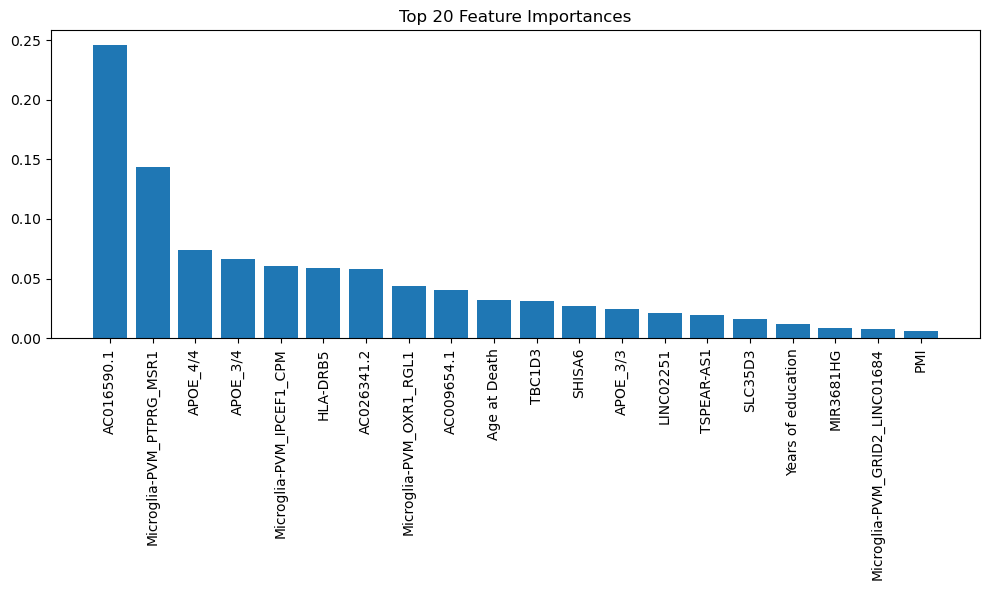

In [4]:
# ============================================================
# Feature Importance for Final Model
# ============================================================

if hasattr(final_model, "feature_importances_"):
    importances = final_model.feature_importances_
    feature_names = X_mtg.columns
    sorted_idx = np.argsort(importances)[::-1]
    print("\nTop 20 Feature Importances:")
    for i in range(20):
        print(f"{feature_names[sorted_idx[i]]}: {importances[sorted_idx[i]]:.4f}")
    # Optional: plot
    plt.figure(figsize=(10, 6))
    plt.bar(range(20), importances[sorted_idx[:20]])
    plt.xticks(range(20), feature_names[sorted_idx[:20]], rotation=90)
    plt.title("Top 20 Feature Importances")
    plt.tight_layout()
    plt.show()
elif hasattr(final_model, "coef_"):
    coefs = final_model.coef_
    feature_names = X_mtg.columns
    sorted_idx = np.argsort(np.abs(coefs))[::-1]
    print("\nTop 20 Coefficient Magnitudes:")
    for i in range(20):
        print(f"{feature_names[sorted_idx[i]]}: {coefs[sorted_idx[i]]:.4f}")
    # Optional: plot
    plt.figure(figsize=(10, 6))
    plt.bar(range(20), coefs[sorted_idx[:20]])
    plt.xticks(range(20), feature_names[sorted_idx[:20]], rotation=90)
    plt.title("Top 20 Coefficient Magnitudes")
    plt.tight_layout()
    plt.show()
else:
    print("Feature importances are not available for this model type.")
# ============================================================

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def plot_gt_vs_pred(ground_truth, prediction, title="Ground Truth vs Prediction per Donor"):
    # Extract donor IDs
    donor_ids = np.array(ground_truth.index.tolist())
    truth = np.array(ground_truth)
    pred = np.array(prediction)

    # Sort by ground truth values
    order = np.argsort(truth)
    donor_ids = donor_ids[order]
    truth = truth[order]
    pred = pred[order]

    # Plot
    plt.figure(figsize=(20, 6))
    plt.plot(donor_ids, truth, label="Ground Truth", marker='o')
    plt.plot(donor_ids, pred, label="Prediction", marker='x', linestyle='--')

    plt.xlabel("Donor ID")
    plt.ylabel("Value")
    plt.title(title)

    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


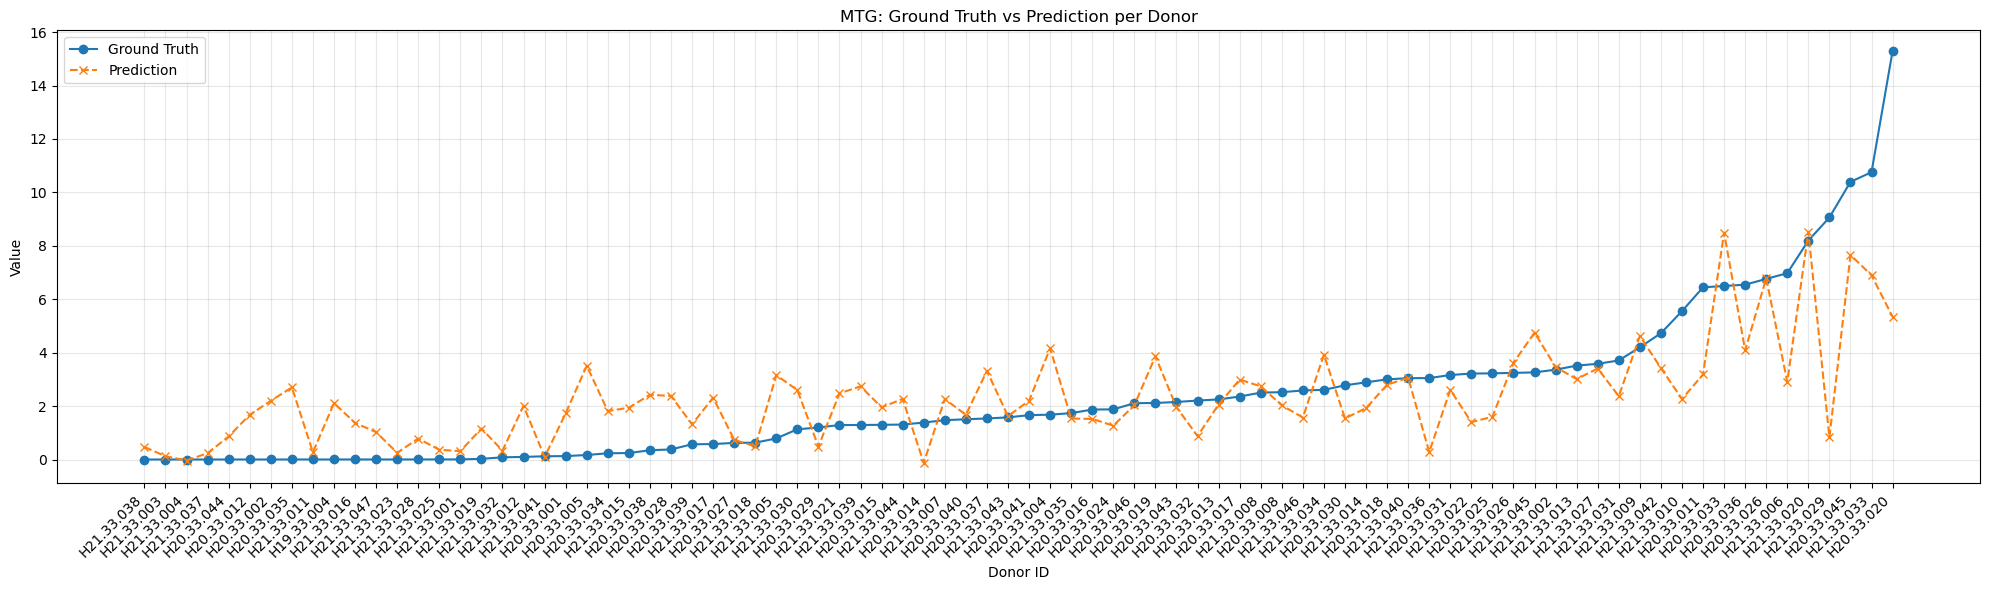

In [ ]:
plot_gt_vs_pred(y_mtg, y_mtg_pred, title="MTG: Ground Truth vs Prediction per Donor")


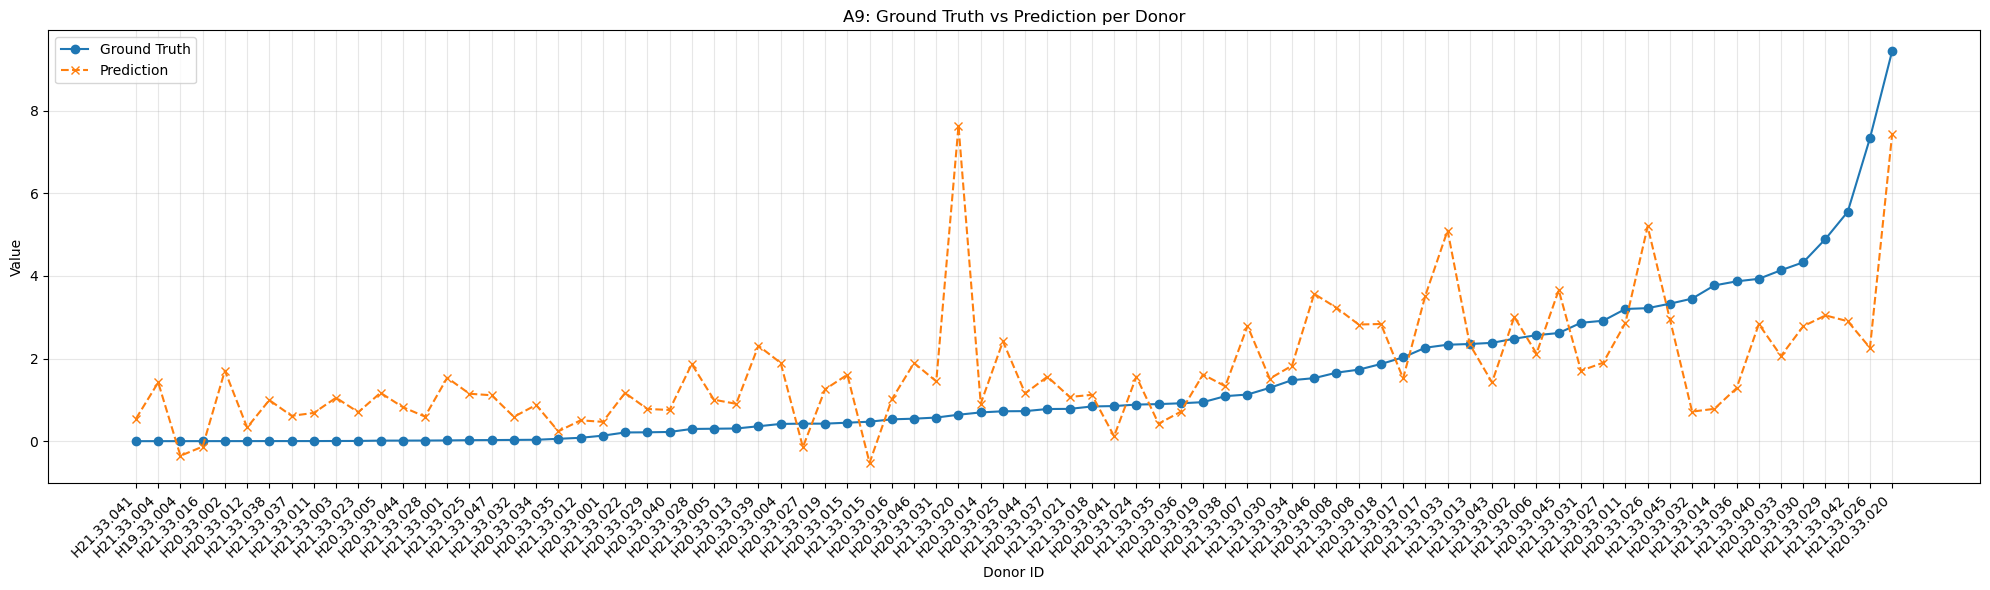

In [ ]:
plot_gt_vs_pred(y_a9, y_a9_pred, title="A9: Ground Truth vs Prediction per Donor")